# Logistic Regression: A Comprehensive Guide

Logistic Regression is a fundamental algorithm in machine learning used for classification tasks. Unlike linear regression which predicts continuous values, logistic regression predicts the probability of an instance belonging to a certain class. It's a supervised learning algorithm that helps us solve binary classification problems (e.g., yes/no, true/false, 0/1).

In this notebook, we'll cover:
1. Basic concepts of Logistic Regression
2. Data preparation and visualization for classification
3. Model implementation
4. Using scikit-learn for Logistic Regression
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

This notebook explains how to use logistic regression, a method for making predictions about categories.

Imagine you want to predict whether a student will pass or fail an exam based on how many hours they studied. You collect data (hours studied and pass/fail result) and find a rule that separates the 'pass' group from the 'fail' group. This rule helps you guess whether a new student will pass or fail based on their study hours.

Here's what happens in the code below:
1. We create some example data where the outcome is either 0 or 1 (like fail or pass).
2. We use a computer to find the best decision boundary that separates the two groups.
3. We show how to do this step-by-step (from scratch) and also using a popular library called scikit-learn.
4. We check how good our rule is at making correct predictions.

In short: The code teaches you how to use a model to classify data into groups and how to check if your classifications are accurate.

In [2]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'\"{pip_path}\" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.
Required libraries installed in the virtual environment.


# 1. Required Libraries

Let's start by importing the necessary libraries:
- NumPy: For numerical computations
- Pandas: For data manipulation
- Matplotlib: For basic plotting
- Seaborn: For statistical visualizations
- Scikit-learn: For machine learning tools

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.datasets import make_classification

# Set the style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

For logistic regression, we need a dataset with distinct classes. We'll create a synthetic dataset where the points can be separated into two groups. This is a binary classification problem.

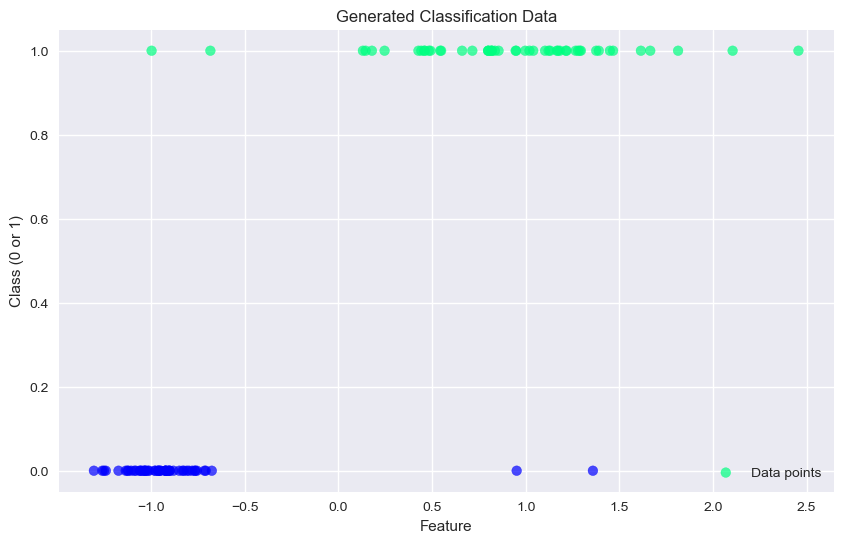

In [4]:
# Generate a binary classification dataset
X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.1,
    random_state=42
)

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, c=y, cmap='winter', alpha=0.7, label='Data points')
plt.xlabel('Feature')
plt.ylabel('Class (0 or 1)')
plt.title('Generated Classification Data')
plt.legend()
plt.grid(True)
plt.show()

# 3. Implementing Logistic Regression

To understand the inner workings of logistic regression, let's build it.

Key concepts:
1. **Sigmoid Function**: This function maps any real value into a value between 0 and 1, which we interpret as a probability.
   - Equation: σ(z) = 1 / (1 + e⁻ᶻ)

2. **Cost Function**: Binary Cross-Entropy or Log Loss. This measures how well the model's predicted probabilities match the actual class labels.

3. **Gradient Descent**: An algorithm to find the optimal parameters (weights and bias) by iteratively minimizing the cost function.

### A Simple Look at the Sigmoid Function

Imagine you have a special machine. You can feed any number into it—positive, negative, big, or small. No matter what number you put in, this machine always gives you back a number between 0 and 1.

- If you put in a very large positive number (like 1,000), the machine gives you a number very close to 1.
- If you put in a very large negative number (like -1,000), it gives you a number very close to 0.
- If you put in the number 0, it gives you exactly 0.5.

This machine is the **Sigmoid Function**.

#### Why is this useful? (Its Significance)

In machine learning, especially for classification problems, we often want to know the **probability** of something happening. For example, "What is the probability that this email is spam?" or "What is the chance this customer will buy the product?"

Probabilities are always between 0 (impossible) and 1 (certain).

The sigmoid function is perfect for this job! It takes the raw output from our machine learning model (which could be any number) and "squashes" it into a value between 0 and 1. We can then treat this value as a probability.

#### Why should you use it in Logistic Regression?

Logistic regression is used to decide between two categories (like "Spam" or "Not Spam").

1.  The model first calculates a "score" based on the input data. This score can be any number.
2.  We then pass this score through the sigmoid function.
3.  The result is a probability. For example, a result of 0.9 could mean "There is a 90% probability that this email is spam."

Based on this probability, we can make a decision. A common rule is: if the probability is greater than 0.5, we classify it as "Spam." If it's less than 0.5, we classify it as "Not Spam."

In short, the sigmoid function acts as a bridge, converting the model's raw, unbounded score into a meaningful probability that we can use to make a clear decision. It's the key ingredient that turns a linear model into a classification model.

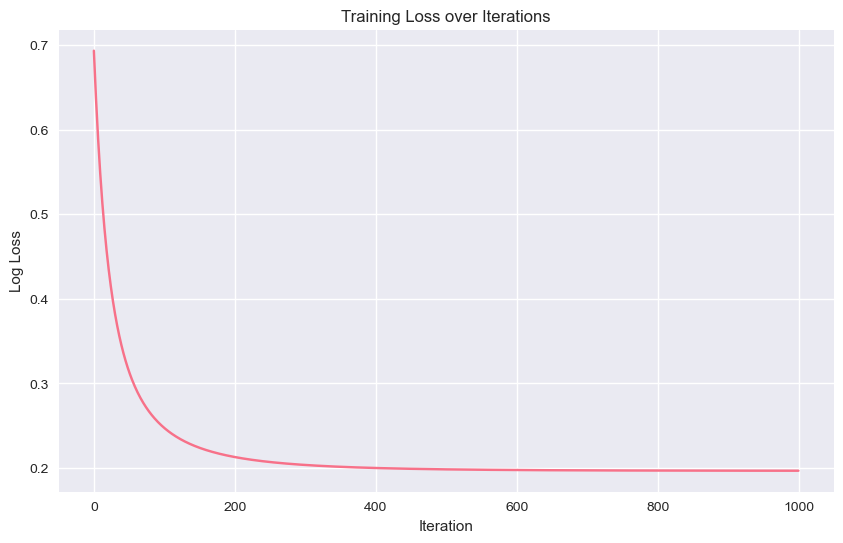

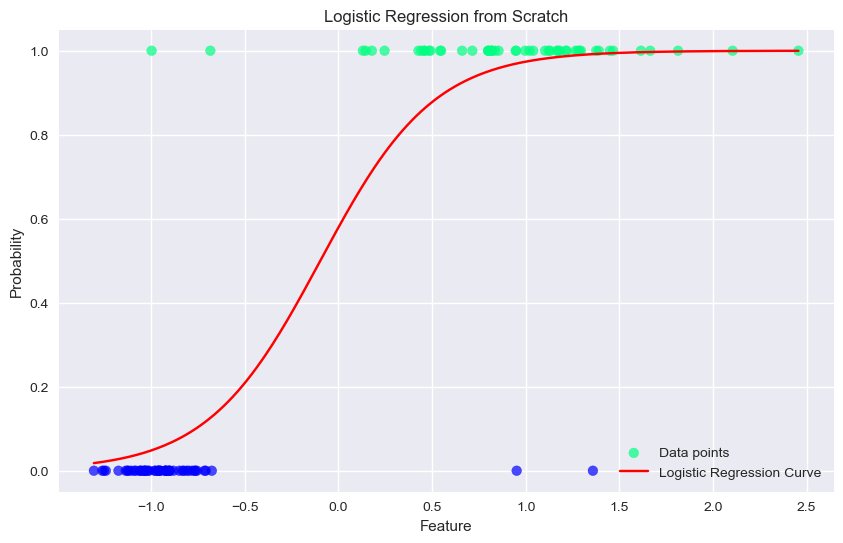

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.history = {'loss': []}

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = - (1/n_samples) * np.sum(y * np.log(y_predicted) + (1-y) * np.log(1-y_predicted))
            self.history['loss'].append(loss)

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        y_predicted_proba = self.predict_proba(X)
        return [1 if i > threshold else 0 for i in y_predicted_proba]

# Train the model
model_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)
model_scratch.fit(X, y)

# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(model_scratch.history['loss'])
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, c=y, cmap='winter', alpha=0.7, label='Data points')
x_test = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_test_proba = model_scratch.predict_proba(x_test)
plt.plot(x_test, y_test_proba, color='red', label='Logistic Regression Curve')
plt.xlabel('Feature')
plt.ylabel('Probability')
plt.title('Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

# 4. Using Scikit-learn's Logistic Regression

Now let's use scikit-learn's optimized implementation of Logistic Regression. This is the standard approach in practice.

Coefficient: 2.4155
Intercept: 0.0272

Model Performance:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        13

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



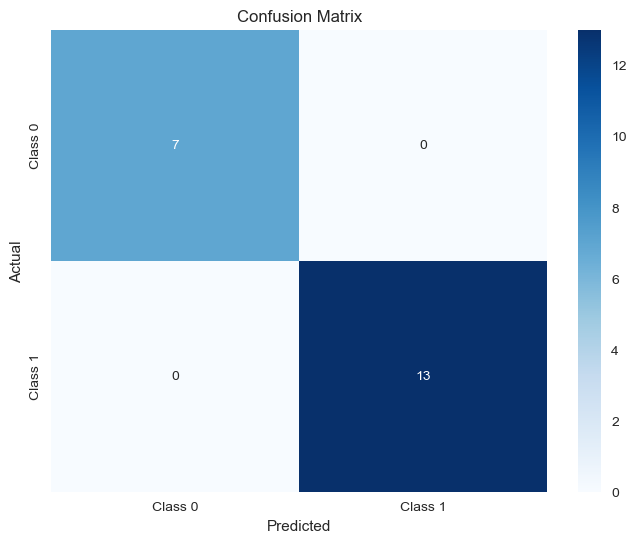

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model_sklearn = LogisticRegression()
model_sklearn.fit(X_train, y_train)

# Make predictions
y_pred = model_sklearn.predict(X_test)

# Print the model parameters
print(f"Coefficient: {model_sklearn.coef_[0][0]:.4f}")
print(f"Intercept: {model_sklearn.intercept_[0]:.4f}")

# Evaluate the model
print("\nModel Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 5. Conclusion and Key Takeaways

1. **Logistic Regression Basics**:
   - A classification algorithm that predicts the probability of a binary outcome.
   - Uses the sigmoid function to map predictions to a 0-1 scale.

2. **Implementation Approaches**:
   - Helps understand the core concepts like the sigmoid function and log loss.
   - Scikit-learn: The standard, optimized, and practical approach.

3. **Model Evaluation for Classification**:
   - **Accuracy**: Overall correctness of the model.
   - **Confusion Matrix**: Shows true positives, true negatives, false positives, and false negatives.
   - **Precision, Recall, F1-score**: Provide more detailed insights into performance, especially for imbalanced datasets.

4. **Best Practices**:
   - Split data into training and testing sets to evaluate performance on unseen data.
   - Feature scaling can be important for logistic regression, especially when using regularization.
   - Understand the business problem to choose the right evaluation metric (e.g., precision vs. recall).

# Essential Interview Questions & Answers for Logistic Regression

### Basic Concepts

**1. What is logistic regression and how does it differ from linear regression?**
- Linear regression predicts continuous values (like prices or temperatures)
- Logistic regression predicts probabilities of categorical outcomes (like yes/no, pass/fail)
- While linear regression outputs any number, logistic regression outputs values between 0 and 1

**2. What is the sigmoid function and why is it crucial in logistic regression?**
- The sigmoid function transforms any input into a value between 0 and 1: σ(z) = 1/(1 + e⁻ᶻ)
- It's essential because it converts the linear combination of features into probabilities
- The steepest part of the sigmoid is around 0, making it sensitive to changes near the decision boundary

**3. How does the logistic regression model make predictions?**
1. Computes a linear combination of features (like linear regression)
2. Passes this through the sigmoid function
3. Outputs probability between 0 and 1
4. Classifies based on a threshold (usually 0.5)

### Training Process

**4. What is the cost function in logistic regression and why not use MSE?**
- Uses Binary Cross-Entropy (Log Loss): -y*log(h(x)) - (1-y)*log(1-h(x))
- MSE isn't used because with sigmoid function it creates a non-convex optimization problem
- Binary Cross-Entropy ensures a convex optimization problem with a global minimum

**5. How does gradient descent work in logistic regression?**
- Iteratively updates weights to minimize the cost function
- Computes gradients of the cost with respect to each parameter
- Takes steps proportional to the learning rate in the direction of steepest descent

**6. What is the role of the learning rate?**
- Controls how large steps we take during gradient descent
- Too high: might overshoot the minimum
- Too low: slow convergence
- Need to find the right balance for effective training

### Model Evaluation

**7. What metrics are used to evaluate logistic regression models?**
- Accuracy: Overall correct predictions
- Precision: Accuracy of positive predictions
- Recall: Ability to find all positive cases
- F1-Score: Harmonic mean of precision and recall
- ROC Curve and AUC: Overall model performance across thresholds

**8. What is a confusion matrix and what does it tell us?**
- 2x2 matrix showing:
  - True Positives (TP): Correctly predicted positives
  - True Negatives (TN): Correctly predicted negatives
  - False Positives (FP): Incorrectly predicted positives
  - False Negatives (FN): Incorrectly predicted negatives

**9. When should you use precision vs recall?**
- Use precision when false positives are costly (e.g., spam detection)
- Use recall when false negatives are costly (e.g., disease detection)
- Use F1-score when you need to balance both

### Advanced Concepts

**10. What is the decision boundary in logistic regression?**
- The surface that separates different classes
- Points where probability equals 0.5
- Linear in original feature space
- Can become non-linear using polynomial features

**11. How can logistic regression handle multiple classes?**
- One-vs-Rest (OvR): Train binary classifier for each class
- One-vs-One: Train classifier for each pair of classes
- Multinomial: Using softmax instead of sigmoid

**12. What is regularization in logistic regression?**
- L1 (Lasso): Adds absolute value of coefficients to cost
- L2 (Ridge): Adds squared coefficients to cost
- Helps prevent overfitting
- Can lead to feature selection (L1)

### Practical Considerations

**13. What are the key assumptions of logistic regression?**
- Independence between observations
- Little or no multicollinearity
- Linear relationship between features and log-odds
- Large sample size relative to number of features

**14. How do you handle imbalanced datasets?**
- Resampling: Oversampling minority or undersampling majority
- Class weights: Assign higher weights to minority class
- SMOTE: Generate synthetic samples
- Adjust classification threshold

**15. When should you choose logistic regression over other models?**
- When you need probabilistic outputs
- When interpretability is important
- When computational resources are limited
- When relationship between features and log-odds is approximately linear
- When you need a baseline model

# Conclusions and Key Takeaways
Despite its name, Logistic Regression is a fundamental model for **classification**, not regression. It extends the concept of linear regression to binary classification by squeezing the output through a sigmoid function.
- **Probabilistic Output**: Highly valued because it outputs a calibrated probability between 0 and 1, rather than just a hard class label.
- **Log-Odds Strategy**: Models the log-odds of a binary event as a linear combination of the input features.
- Can be extended to multi-class classification using the One-vs-Rest strategy or Multinomial Logistic Regression (Softmax).

# Pros and Cons
**Pros:**
- Simple to implement, computationally efficient, and serves as an excellent baseline model.
- Highly interpretable coefficients (representing odds ratios).
- Outputs reliable probabilities, useful when you need confidence scores for predictions.

**Cons:**
- Only identifies linear decision boundaries. Fails on non-linearly separable data.
- Relies on the assumption that features are independent.
- Extremely sensitive to large outliers, similar to linear regression.

# 15 Interview Questions and Answers

1. **Why is it called Logistic Regression if it's a classification algorithm?**
   *Answer*: It is a regression model in that it predicts a continuous value—specifically, the probability that an observation belongs to a particular class (using the logistic function). A threshold is then used to convert that probability into a classification label.

2. **What is the Sigmoid function?**
   *Answer*: An S-shaped mathematical function: `1 / (1 + e^-z)`. It maps the continuous output of a linear equation (`z`) to a value strictly between 0 and 1, representing a probability.

3. **What is Log-Loss (Cross-Entropy Loss)?**
   *Answer*: It is the cost function used by Logistic Regression. It heavily penalizes models that are "confidently wrong". If the true class is 1 and the model predicts a probability of 0.01, the log loss formulation shoots up to infinity aggressively.

4. **Why don't we use Mean Squared Error (MSE) for Logistic Regression?**
   *Answer*: If you feed the non-linear sigmoid activation into the MSE function, the resulting loss landscape becomes non-convex, meaning it has many local minima. Gradient descent runs the risk of getting stuck. Log-loss makes the cost function convex and smooth.

5. **What do the coefficients in Logistic Regression represent?**
   *Answer*: They represent the change in the *log-odds* of the dependent variable for a one-unit change in the predictor variable. By exponentiating a coefficient `e^coef`, you get the Odds Ratio.

6. **How does Logistic Regression handle multi-class problems?**
   *Answer*: It uses the One-vs-Rest (OvR) approach, where it trains N distinct binary classifiers, or Multinomial Logistic Regression, which uses a Softmax function to calculate the simultaneous probabilities for all classes.

7. **Does Logistic Regression require feature scaling?**
   *Answer*: Strictly speaking, unregularized logistic regression doesn't require scaling for the math to hold, but just like Linear Regression, scaling is crucial if you are using Gradient Descent to converge efficiently or if you apply L1/L2 Regularization (which is the default in scikit-learn).

8. **Can Logistic Regression handle non-linear decision boundaries?**
   *Answer*: Natively, no. It draws a straight line (or hyperplane) to separate classes. However, if you explicitly engineer non-linear features (like polynomial terms or interaction terms), the decision boundary can become non-linear relative to the original features.

9. **What happens if the classes are perfectly linearly separable?**
   *Answer*: It leads to a phenomenon called "perfect separation" or "Hauk-Donner effect". The gradient descent algorithm will push the weights towards infinity trying to achieve a perfect 1.0 or 0.0 probability, making the model unstable. Regularization prevents this.

10. **Explain the difference between Probability, Odds, and Log-Odds.**
    *Answer*: Probability (P) is events / total outcomes. Odds is events / non-events (P / 1-P). Log-Odds is taking the natural logarithm of the odds equation. Logistic regression natively predicts the log-odds.

11. **How does adding L1 regularization affect Logistic Regression?**
    *Answer*: It acts as a feature selector. By penalizing the absolute size of the coefficients, it forcibly shrinks the coefficients of less important features exactly to zero, resulting in a sparse, interpretable model.

12. **Is Logistic Regression susceptible to multicollinearity?**
    *Answer*: Yes. If predictor variables are highly correlated, the model will struggle to determine which specific feature is driving the outcome, leading to highly inflated, unstable standard errors for the coefficients.

13. **How is the threshold in Logistic Regression chosen?**
    *Answer*: The default is 0.5. However, in practice, it is chosen based on the business problem using metrics like the ROC curve or Precision-Recall curve to find an optimal balance between false positives and false negatives (e.g., setting a lower threshold for cancer detection to increase recall).

14. **What are the assumptions of Logistic regression?**
    *Answer*: 1) Binary outcome, 2) Independence of observations, 3) Absence of multicollinearity among predictors, 4) Linearity of independent variables and log-odds.

15. **Why is it favored in regulated industries (like banking) over more complex models?**
    *Answer*: Because of its extreme transparency. Modellers can take the model to regulators and explicitly point to a coefficient to prove exactly how much a person's income or credit history affected their likelihood of loan approval.
